# 🌱 O Oráculo da Varanda — Controle Fuzzy de Irrigação

**Mini-Projeto 2 (MP2) — Sistemas Baseados em Conhecimento**

No MP1, o Oráculo usava regras crisp (Experta) para escolher a receita de solo de um vaso. Aqui o problema muda: **quanta água dar?** Conceitos como "solo seco" ou "sol forte" não têm fronteira nítida, e é exatamente essa imprecisão linguística que a lógica fuzzy trata.

## O sistema em uma tabela

| Tipo | Variável | Universo | Termos linguísticos |
|---|---|---|---|
| Entrada | `umidade` (solo) | 0 a 100 % | seco, ideal, encharcado |
| Entrada | `radiacao` (sol direto) | 0 a 10 h/dia | baixa, moderada, intensa |
| Saída | `rega` (volume por vaso) | 0 a 600 ml | baixa, moderada, abundante |

## Como o sistema decide (Mamdani, 5 passos)

1. **Fuzzificação:** os valores de entrada viram graus de pertinência (0 a 1) em cada termo.
2. **Avaliação das regras:** cada regra calcula seu grau de ativação **α** (o "E" é o mínimo dos graus).
3. **Implicação:** o conjunto de saída de cada regra é cortado na altura α.
4. **Agregação:** os conjuntos cortados são unidos pelo máximo.
5. **Defuzzificação:** o **centroide** (centro de massa) da área agregada vira um número em ml.

## Como ler este notebook

Cada seção tem uma explicação **antes** da célula de código (o que vamos fazer) e outra **depois** (o que foi construído ou o que o resultado significa).

1. Variáveis linguísticas e funções de pertinência
2. Base de regras (9 regras, grade 3×3 completa)
3. Casos de teste e interpretação
4. Visualização gráfica
5. Testes personalizados

## Sistema de Inferência Fuzzy para Irrigação Inteligente
Este projeto implementa um sistema de controle baseado em Lógica Fuzzy para determinar o volume ideal de rega para plantas. O sistema toma decisões baseadas em duas variáveis de entrada: a **umidade atual do solo** e a **radiação solar diária**.

A abordagem utiliza regras linguísticas (como "se o solo está seco e o sol está intenso, a rega deve ser abundante") para modelar o raciocínio humano e aplicar a quantidade exata de água necessária.

---
### Preparação do Ambiente
Nesta primeira célula, instalamos a biblioteca `scikit-fuzzy`, que é o motor principal para a lógica fuzzy no Python. Em seguida, importamos o `numpy` para a manipulação de arrays numéricos e os módulos de controle do `skfuzzy`.

In [1]:
# ==============================================================================
# Instalação da dependência obrigatória
# ==============================================================================
!pip install scikit-fuzzy -q

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.4 MB/s eta 0:00:00


### 1. Modelagem do Domínio e Variáveis Linguísticas
Aqui definimos o "universo de discurso" (os limites numéricos) para cada variável:
* **Entrada 1 - Umidade (%)**: De 0 a 100, categorizada em `seco`, `ideal` e `encharcado`.
* **Entrada 2 - Radiação Solar (h/dia)**: De 0 a 10, categorizada em `baixa`, `moderada` e `intensa`.
* **Saída - Volume de Rega (ml)**: De 0 a 600, categorizada em `baixa`, `moderada` e `abundante`.

Utilizamos funções de pertinência trapezoidais (`trapmf`) e triangulares (`trimf`) para mapear a transição suave entre esses estados.

In [2]:
# ==============================================================================
# 1. MODELAGEM DO DOMÍNIO E VARIÁVEIS LINGUÍSTICAS
# ==============================================================================

# Entradas (Antecedentes)
# umidade_solo: 0% a 100%
umidade = ctrl.Antecedent(np.arange(0, 101, 1), 'umidade')
# radiacao_solar: 0 a 10 horas de sol direto por dia
radiacao = ctrl.Antecedent(np.arange(0, 11, 1), 'radiacao')

# Saída (Consequente)
# volume_rega: 0 a 600 ml por vaso
rega = ctrl.Consequent(np.arange(0, 601, 1), 'rega')

# Funções de Pertinência - Umidade do Solo
umidade['seco'] = fuzz.trapmf(umidade.universe, [0, 0, 20, 40])
umidade['ideal'] = fuzz.trimf(umidade.universe, [25, 50, 75])
umidade['encharcado'] = fuzz.trapmf(umidade.universe, [60, 80, 100, 100])

# Funções de Pertinência - Radiação Solar
radiacao['baixa'] = fuzz.trapmf(radiacao.universe, [0, 0, 1.5, 3.5])
radiacao['moderada'] = fuzz.trimf(radiacao.universe, [2.5, 5.0, 7.5])
radiacao['intensa'] = fuzz.trapmf(radiacao.universe, [6.5, 8.5, 10, 10])

# Funções de Pertinência - Volume de Rega
rega['baixa'] = fuzz.trapmf(rega.universe, [0, 0, 100, 200])
rega['moderada'] = fuzz.trimf(rega.universe, [150, 300, 450])
rega['abundante'] = fuzz.trapmf(rega.universe, [400, 500, 600, 600])

#### O que foi construído

Cada termo linguístico é um **conjunto fuzzy**: uma curva que diz, de 0 a 1, o quanto um valor pertence àquele termo. Os termos de uma mesma variável **se sobrepõem de propósito**.

| Variável | Termo | Forma | Parâmetros |
|---|---|---|---|
| umidade | seco | trapezoidal | [0, 0, 20, 40] |
| umidade | ideal | triangular | [25, 50, 75] |
| umidade | encharcado | trapezoidal | [60, 80, 100, 100] |
| radiacao | baixa | trapezoidal | [0, 0, 1.5, 3.5] |
| radiacao | moderada | triangular | [2.5, 5.0, 7.5] |
| radiacao | intensa | trapezoidal | [6.5, 8.5, 10, 10] |
| rega | baixa | trapezoidal | [0, 0, 100, 200] |
| rega | moderada | triangular | [150, 300, 450] |
| rega | abundante | trapezoidal | [400, 500, 600, 600] |

**Por que trapézios nos extremos?** Eles criam um platô de pertinência 1 nas situações de perigo (solo muito seco, muito encharcado, sol muito forte), em que a resposta do sistema precisa ser firme. Nos termos do meio, os triângulos têm um único pico.

**Exemplo de sobreposição:** com umidade = 30 %, o solo é *seco* em grau 0,5 e *ideal* em grau 0,2 ao mesmo tempo. Não existe um limiar que "vira a chave", e isso elimina os *cliff edges* (saltos bruscos) da lógica crisp do MP1.

> Esta célula só define variáveis e curvas, por isso não gera saída. Os gráficos aparecem na seção 4.

### 2. Base de Regras
O "cérebro" do sistema. Criamos 9 regras que cobrem todas as combinações possíveis (3 estados de umidade x 3 estados de radiação). As regras determinam ações lógicas, como:
* **Regra 1**: Se está muito seco e com sol intenso, regue com abundância.
* **Regra 6**: Se a umidade está ideal e há pouco sol, uma rega baixa é suficiente.

Após definir as regras, instanciamos o `ControlSystem` e o simulador que fará os cálculos matemáticos.

In [3]:
# ==============================================================================
# 2. BASE DE REGRAS
# ==============================================================================

r1 = ctrl.Rule(umidade['seco'] & radiacao['intensa'], rega['abundante'])
r2 = ctrl.Rule(umidade['seco'] & radiacao['moderada'], rega['abundante'])
r3 = ctrl.Rule(umidade['seco'] & radiacao['baixa'], rega['moderada'])

r4 = ctrl.Rule(umidade['ideal'] & radiacao['intensa'], rega['moderada'])
r5 = ctrl.Rule(umidade['ideal'] & radiacao['moderada'], rega['baixa'])
r6 = ctrl.Rule(umidade['ideal'] & radiacao['baixa'], rega['baixa'])

r7 = ctrl.Rule(umidade['encharcado'] & radiacao['intensa'], rega['baixa'])
r8 = ctrl.Rule(umidade['encharcado'] & radiacao['moderada'], rega['baixa'])
r9 = ctrl.Rule(umidade['encharcado'] & radiacao['baixa'], rega['baixa'])

# Criação do Controlador e da Simulação
oraculo_ctrl = ctrl.ControlSystem([r1, r2, r3, r4, r5, r6, r7, r8, r9])
oraculo_sim = ctrl.ControlSystemSimulation(oraculo_ctrl)

#### O que foi construído

Com 2 variáveis e 3 termos cada, a grade completa tem 3² = **9 regras**, todas as combinações cobertas, sem lacunas:

| Umidade \ Radiação | Baixa | Moderada | Intensa |
|---|---|---|---|
| **Seco** | moderada (R3) | abundante (R2) | abundante (R1) |
| **Ideal** | baixa (R6) | baixa (R5) | moderada (R4) |
| **Encharcado** | baixa (R9) | baixa (R8) | baixa (R7) |

**A lógica agronômica:**
- Solo seco com sol moderado ou intenso exige reposição alta. Com pouco sol a evaporação é lenta, então uma rega abundante acumularia água no fundo do vaso (por isso R3 é "moderada").
- Solo ideal só precisa de mais água se o sol for intenso (R4); nos demais casos basta manutenção leve.
- Solo encharcado pede rega baixa em qualquer cenário, para evitar o apodrecimento da raiz.

**Detalhes técnicos:**
- O `&` de cada regra é o **mínimo** dos dois graus de pertinência. O resultado é o grau de ativação **α** da regra.
- O `ControlSystem` é a **base de conhecimento** (variáveis, conjuntos e regras) e o `ControlSystemSimulation` é o **motor de inferência**. As duas partes ficam separadas, como em qualquer SBC.
- Nada é calculado ainda: a inferência só roda quando chamamos `compute()` na seção 3.

### 3. Casos de Teste e Interpretação
Nesta etapa, testamos o sistema (o "oráculo") com cenários reais para validar seu comportamento. O processo de **defuzzificação** (usando o método do centroide) transforma a saída fuzzy combinada de volta em um valor numérico exato em mililitros (ml).
* Observamos como o sistema aumenta a água na seca severa, mantém uma rega leve quando o solo está ideal e devolve um valor intermediário quando duas regras com "opiniões" diferentes disparam ao mesmo tempo.

In [4]:
# ==============================================================================
# 3. CASOS DE TESTE E INTERPRETAÇÃO
# ==============================================================================

def testar_oraculo_fuzzy(nome_teste, umi_val, rad_val):
    print(f"\n--- TESTE: {nome_teste} ---")
    oraculo_sim.input['umidade'] = umi_val
    oraculo_sim.input['radiacao'] = rad_val
    oraculo_sim.compute()
    resultado = oraculo_sim.output['rega']
    print(f"Entradas: Umidade = {umi_val}%, Radiação = {rad_val}h")
    print(f"Saída Defuzzificada (Centroide): {resultado:.2f} ml de água")
    return resultado

# TESTE 1: Caso Extremo - Seca Severa sob Sol Pleno
testar_oraculo_fuzzy("Seca Severa + Sol Intenso", umi_val=10, rad_val=9)

# TESTE 2: Caso de Equilíbrio (Manutenção) - Solo Ideal em Meia Sombra
testar_oraculo_fuzzy("Condições Ideais e Equilibradas", umi_val=50, rad_val=5)

# TESTE 3: Caso de Transição - Solo Parcialmente Seco em Meia-sombra
testar_oraculo_fuzzy("Solo Parcialmente Seco + Meia-sombra (Transição)", umi_val=30, rad_val=5)


--- TESTE: Seca Severa + Sol Intenso ---
Entradas: Umidade = 10%, Radiação = 9h
Saída Defuzzificada (Centroide): 522.22 ml de água

--- TESTE: Condições Ideais e Equilibradas ---
Entradas: Umidade = 50%, Radiação = 5h
Saída Defuzzificada (Centroide): 77.78 ml de água

--- TESTE: Solo Parcialmente Seco + Meia-sombra (Transição) ---
Entradas: Umidade = 30%, Radiação = 5h
Saída Defuzzificada (Centroide): 385.70 ml de água


np.float64(385.69721115537857)

#### Resultados e interpretação

`testar_oraculo_fuzzy(nome_teste, umi_val, rad_val)` roda uma inferência completa. Atribuir `input[...]` faz a **fuzzificação** e `compute()` executa o restante do Mamdani, terminando na **defuzzificação por centroide**. O parâmetro `nome_teste` é só um rótulo para o `print`: não entra em nenhuma conta.

| Teste | Entradas | Regras que disparam | Saída |
|---|---|---|---|
| Seca severa + sol intenso | umidade 10 %, radiação 9 h | R1 (α = 1) → abundante | **522,22 ml** |
| Condições ideais | umidade 50 %, radiação 5 h | R5 (α = 1) → baixa | **77,78 ml** |
| Transição | umidade 30 %, radiação 5 h | R2 (α = 0,5) → abundante; R5 (α = 0,2) → baixa | **385,70 ml** |

- **Teste 1:** o solo é totalmente "seco" e o sol totalmente "intenso", então só a R1 dispara, com força máxima. A saída é o centro de massa de "abundante" inteiro: cerca de meio litro por vaso.
- **Teste 2:** o solo está no pico de "ideal" e o sol no pico de "moderada". Só a R5 dispara e a saída é o centro de massa de "baixa" inteiro: rega de manutenção.
- **Teste 3:** é o caso mais interessante. O solo é parcialmente seco (0,5) e parcialmente ideal (0,2), então **duas regras que discordam disparam juntas**. A área de "abundante" é maior, o que puxa o resultado para cima, mas a R5 o puxa para baixo. O 385,70 ml cai na região de "moderada", embora nenhuma regra peça "moderada": é o compromisso do Mamdani, e mostra que a saída varia de forma gradual.

##### Limitação observada

**77,78 ml é o menor volume que o sistema consegue recomendar**, pois é o centroide do conjunto "baixa" inteiro. Qualquer cenário em que só "baixa" dispara com força máxima (por exemplo, solo encharcado com umidade 85 % e radiação 1 h) devolve exatamente o mesmo valor. O modelo diferencia *regar muito* de *regar pouco*, mas não diferencia *manutenção* de *suspender a rega*. Uma melhoria futura seria criar um termo de saída "nula" para o solo encharcado.

### 4. Visualização Gráfica
As visualizações geradas pelo `matplotlib` nos ajudam a entender graficamente:
1. Como as funções de pertinência de umidade, radiação e rega se sobrepõem no espaço.
2. O resultado da defuzzificação (último gráfico), onde a área preenchida mostra a ativação das regras para o último cenário testado, e a **linha vertical preta espessa** indica o Centroide, que é o valor numérico final da recomendação de rega.

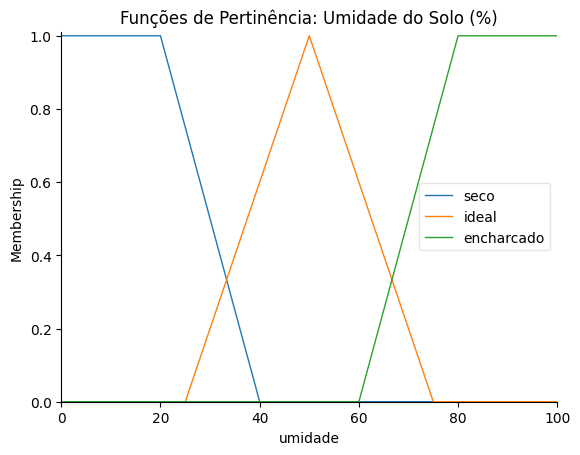

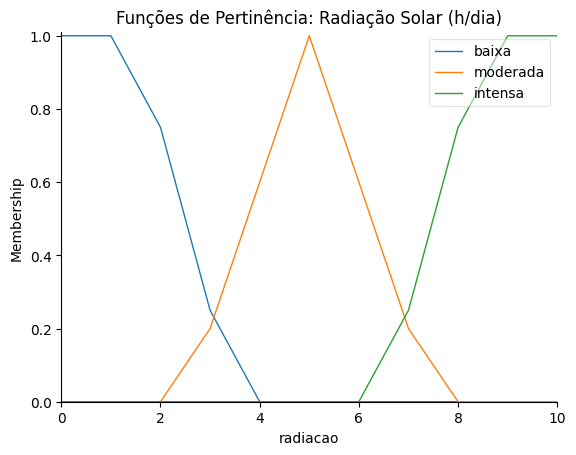

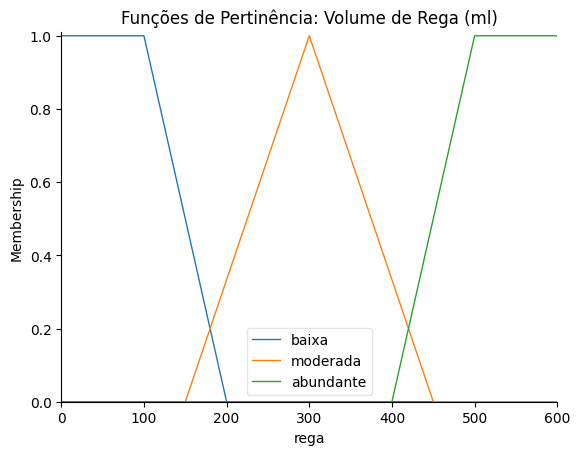

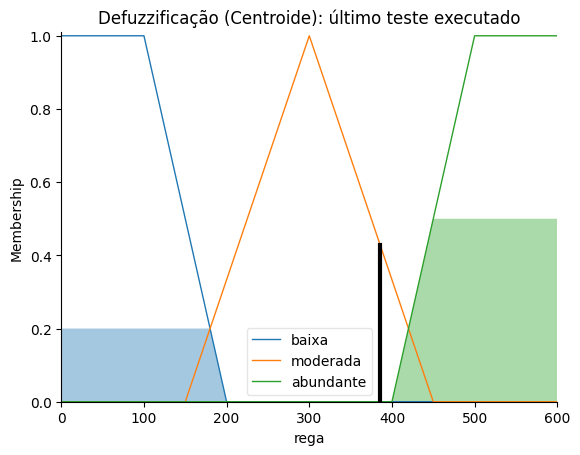

In [5]:
import os
import matplotlib.pyplot as plt

os.makedirs("img", exist_ok=True)

# 1. Umidade do solo
umidade.view()
plt.title("Funções de Pertinência: Umidade do Solo (%)")
plt.savefig("img/umidade.png", dpi=150, bbox_inches="tight")

# 2. Radiação solar
radiacao.view()
plt.title("Funções de Pertinência: Radiação Solar (h/dia)")
plt.savefig("img/radiacao.png", dpi=150, bbox_inches="tight")

# 3. Volume de rega
rega.view()
plt.title("Funções de Pertinência: Volume de Rega (ml)")
plt.savefig("img/rega.png", dpi=150, bbox_inches="tight")

# 4. Defuzzificação (usa o último teste executado; na ordem do notebook, o teste 3)
rega.view(sim=oraculo_sim)
plt.title("Defuzzificação (Centroide): último teste executado")
plt.savefig("img/defuzzificacao.png", dpi=150, bbox_inches="tight")

plt.show()

#### Como ler os gráficos

- **Gráficos 1 a 3:** cada curva mostra o grau de pertinência (0 a 1) de cada valor do universo a um termo. Onde duas curvas se cruzam é uma região de transição: o mesmo valor pertence a dois termos ao mesmo tempo, e é isso que faz a saída variar de forma contínua.
- **Gráfico 4 (defuzzificação):** a área colorida é a **agregação** dos conjuntos de saída cortados em α, e a **linha vertical preta** marca o centroide, o volume de rega recomendado. Ele usa o **último teste executado**. Rodando as células em ordem, é o teste 3 (umidade 30 %, radiação 5 h), em que "abundante" aparece cortado em 0,5 e "baixa" em 0,2. Se você rodar a seção 5 antes e depois repetir esta célula, o gráfico passa a mostrar o teste personalizado.
- As imagens também são salvas na pasta `img/` (`umidade.png`, `radiacao.png`, `rega.png`, `defuzzificacao.png`) para uso no README. No Colab essa pasta é temporária: baixe os arquivos antes de encerrar a sessão.

*(Fim das execuções do sistema fuzzy)*

### 5. Testes Personalizados
Use a célula abaixo para testar o sistema com seus próprios valores de umidade e radiação.

In [6]:
# Defina seus valores aqui:
minha_umidade = 65  # Valor entre 0 e 100 (%)
minha_radiacao = 7  # Valor entre 0 e 10 (horas/dia)

# Chamando a função de teste
resultado_customizado = testar_oraculo_fuzzy(
    nome_teste="Meu Teste Personalizado",
    umi_val=minha_umidade,
    rad_val=minha_radiacao
)



--- TESTE: Meu Teste Personalizado ---
Entradas: Umidade = 65%, Radiação = 7h
Saída Defuzzificada (Centroide): 215.86 ml de água


#### Interpretando o teste personalizado

Com os valores padrão (umidade 65 %, radiação 7 h), **quatro regras disparam ao mesmo tempo**:

| Regra | Graus de pertinência | α | Aponta para |
|---|---|---|---|
| R4 | ideal (0,4) e intensa (0,25) | 0,25 | moderada |
| R5 | ideal (0,4) e moderada (0,2) | 0,2 | baixa |
| R7 | encharcado (0,25) e intensa (0,25) | 0,25 | baixa |
| R8 | encharcado (0,25) e moderada (0,2) | 0,2 | baixa |

Na **agregação** vale o máximo: "baixa" fica cortada em max(0,2; 0,25; 0,2) = 0,25 e "moderada" em 0,25. O centroide fica em **215,86 ml**, entre os dois conjuntos. Repare que três regras apontam para "baixa" e só uma para "moderada", mas elas não funcionam como votos: como a agregação usa o máximo, cada termo de saída entra apenas com a sua regra mais forte.

**Experimente:**
- `85 %` de umidade e `1 h` de radiação devolvem **77,78 ml**, o mesmo valor do teste 2 (a limitação descrita na seção 3).
- `10 %` e `9 h` reproduzem o teste 1 (**522,22 ml**).
- Varie a umidade de 5 em 5 mantendo a radiação fixa e observe a rega mudar de forma contínua, sem saltos.